<a href="https://colab.research.google.com/github/di-claro-batera/faculdade_data_science/blob/main/Autoencoders_aplica%C3%A7%C3%A3o_e_pr%C3%A1tica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Autoencoders com o MNIST

* Carregamento dos pacotes
* Carregamento dos dados (MNIST)
* Modelo Raso
* Modelo Profundo

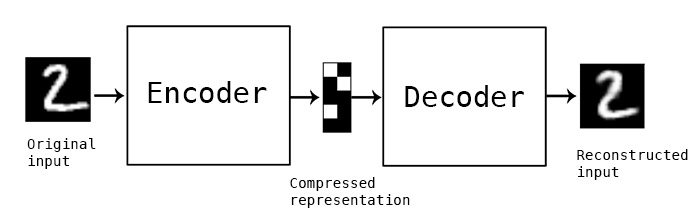

# Estrutura padrão de um autoencoder:
* Camada de Codificação (Encoder)
* Camada de Decodificação (Decoder)
* Espaço Latente

# Pacotes

In [1]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
import keras.datasets as kds

import numpy as np
import matplotlib.pyplot as plt

# Bibliotecas utilizadas para projeção/redução da dimensionalidade
from sklearn.manifold import TSNE
from sklearn.decomposition import KernelPCA, PCA

# Carregamento dos dados (MNIST)

MNIST-Fashion

Fonte: https://en.wikipedia.org/wiki/MNIST_database

No Keras: https://keras.io/api/datasets/mnist/

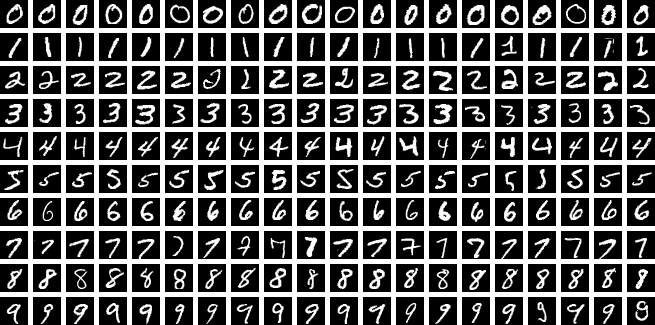

In [2]:
num_classes = 10
input_shape = (28, 28, 1)

# Carga dos dados (keras.datasets)
(x_train, y_train), (x_test, y_test) = kds.mnist.load_data()

# Normalização das features
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
print(x_train.shape)
print(x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 784)
(10000, 784)


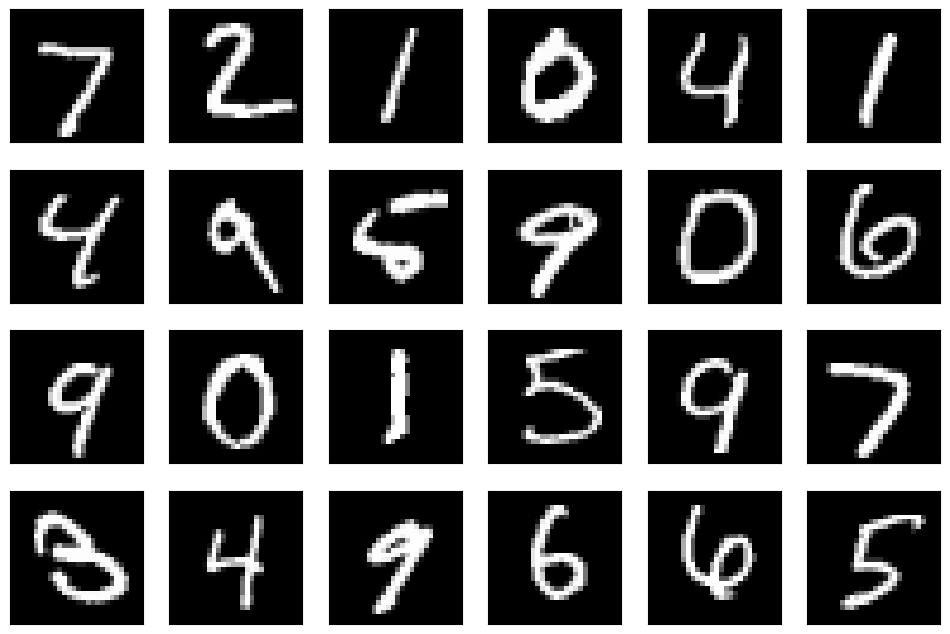

In [4]:
plt.figure(figsize=(12, 8))
for i in range(24):
  ax = plt.subplot(4, 6, i + 1)
  plt.imshow(x_test[i].reshape(28, 28))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
plt.show()

# Autoencoder 01: Autoencoder Raso

## Definição do Modelo

In [5]:
encoding_dim = 12

input_img = keras.Input(shape=(784,))
encoded = layers.Dense(encoding_dim, activation='relu')(input_img)
decoded = layers.Dense(784, activation='sigmoid')(encoded)

autoencoder01 = keras.Model(input_img, decoded)
autoencoder01.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12)             │         9,420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 784)            │        10,192 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,612 (76.61 KB)

 Trainable params: 19,612 (76.61 KB)

 Non-trainable params: 0 (0.00 B)

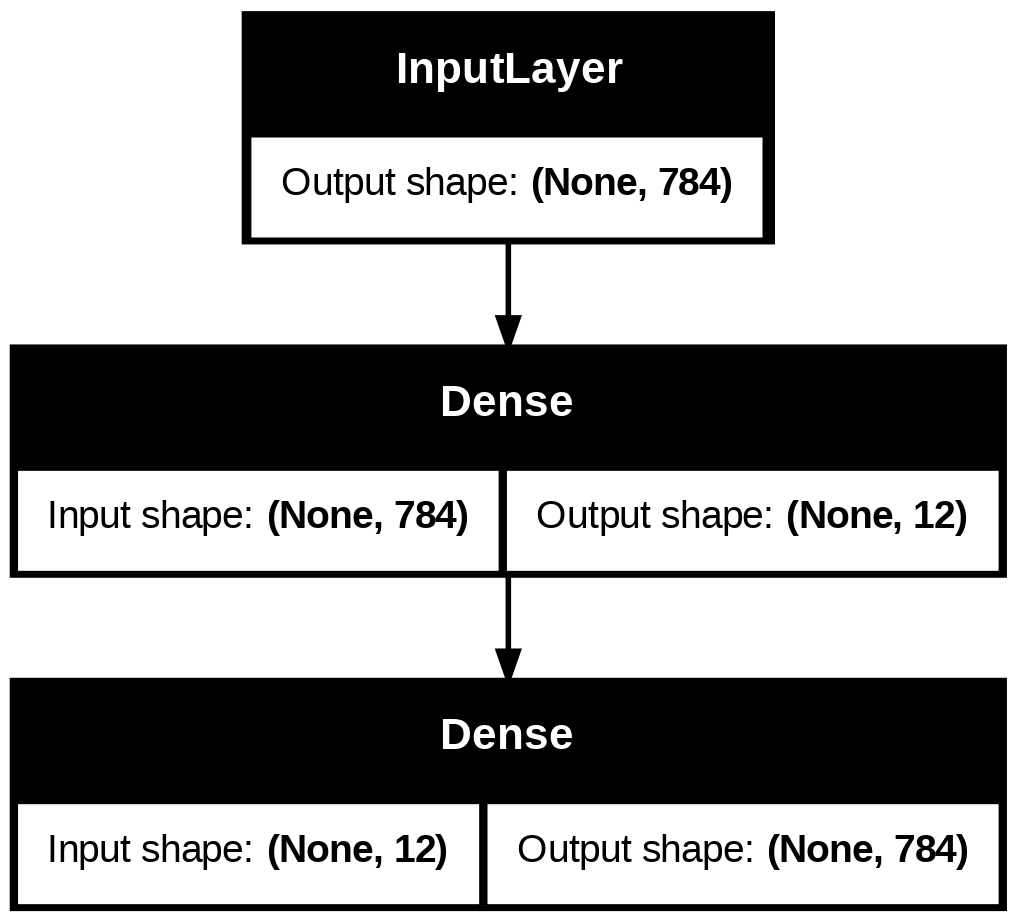

In [6]:
tf.keras.utils.plot_model(autoencoder01, show_shapes=True)

# Criação dos modelos Encoder e Decoder

In [8]:
encoder01 = keras.Model(input_img, decoded)

encoded_input = keras.Input(shape=(encoding_dim,))
decoded_layer = autoencoder01.layers[-1]
decoder01 = keras.Model(encoded_input, decoded_layer(encoded_input))

# Treinamento do Autoencoder 01

In [9]:
autoencoder01.compile(optimizer='adam', loss='binary_crossentropy')
history = autoencoder01.fit(x_train, x_train,
                            epochs=50,
                            batch_size=256,
                            shuffle=True,
                            validation_data=(x_test, x_test),
                            verbose=1) # usar 1 ou 2 para observar a evolução por época

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.4364 - val_loss: 0.2358
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2220 - val_loss: 0.1912
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1881 - val_loss: 0.1752
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1737 - val_loss: 0.1643
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.1639 - val_loss: 0.1590
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1591 - val_loss: 0.1566
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1570 - val_loss: 0.1547
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1556 - val_loss: 0.1531
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.1539 - val_loss: 0.1520
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1525 - val_loss: 0.1506
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1519 - val_loss: 0.1495
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/s

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


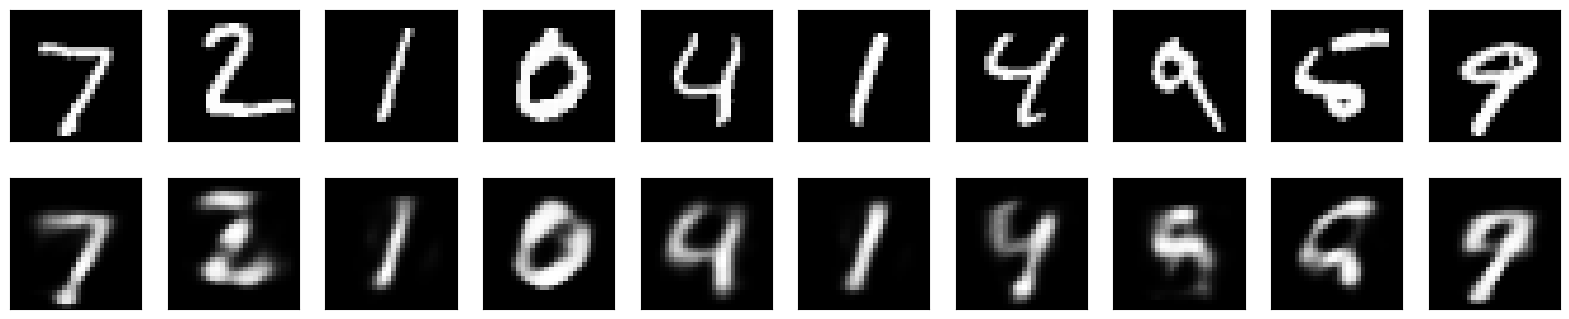

In [12]:
decoded_imgs01 = autoencoder01.predict(x_test)

n = 10 # imagens visualizadas
plt.figure(figsize=(20, 4))
for i in range(n):
  # Original
  ax = plt.subplot(2, n, i + 1)
  plt.imshow(x_test[i].reshape(28, 28))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

  # Reconstrução
  ax = plt.subplot(2, n, i + 1 + n)
  plt.imshow(decoded_imgs01[i].reshape(28, 28))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
plt.show()

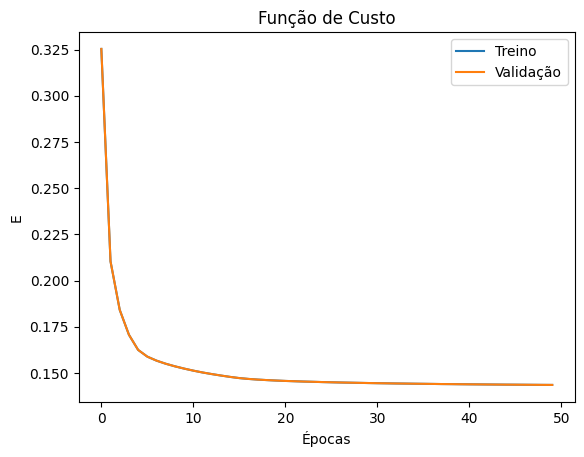

In [13]:
plt.figure()
plt.plot(history.history["loss"], label = "Treino")
plt.plot(history.history["loss"], label = "Validação")
plt.title("Função de Custo")
plt.ylabel("E")
plt.xlabel("Épocas")
plt.legend()
plt.show()

# Projeção com PCA

https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


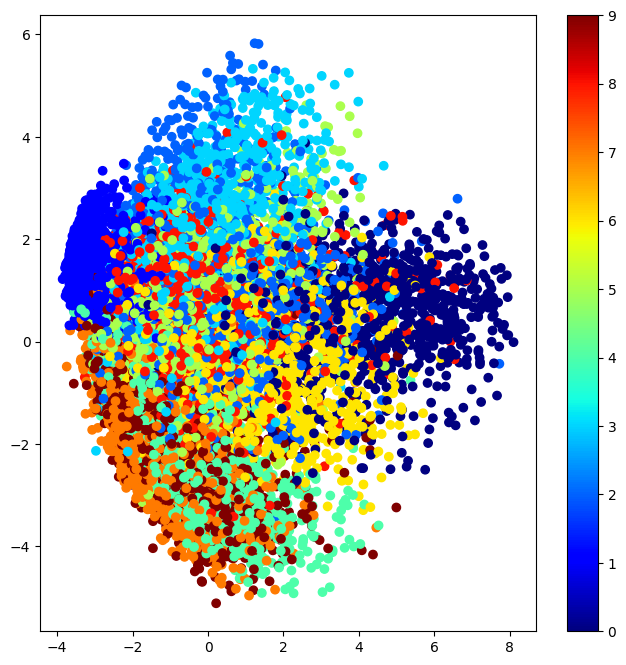

In [14]:
x_test_encoded = encoder01.predict(x_test, batch_size=256)

x_emb = PCA(n_components=2).fit_transform(x_test_encoded)

plt.figure(figsize=(8, 8))
plt.scatter(x_emb[:, 0], x_emb[:, 1], c=y_test, cmap=plt.cm.jet)
plt.colorbar()
plt.show()

# Projeção com t-SNE

https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html

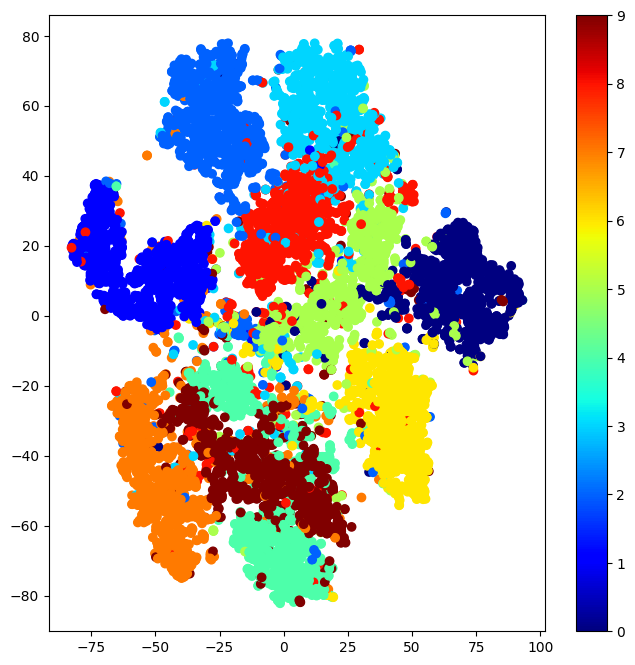

In [15]:
x_emb = TSNE(n_components=2).fit_transform(x_test_encoded)

plt.figure(figsize=(8, 8))
plt.scatter(x_emb[:, 0], x_emb[:, 1], c=y_test, cmap=plt.cm.jet)
plt.colorbar()
plt.show()

# Autoencoder 02: Autoencoder profundo

## Definição do modelo

In [16]:
encoding_dim = 12

input_img = keras.Input(shape=(784,))
encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(64, activation='relu')(encoded)
encoded = layers.Dense(encoding_dim, activation='relu')(encoded)
decoded = layers.Dense(64, activation='relu')(encoded)
decoded = layers.Dense(128, activation='relu')(decoded)
decoded = layers.Dense(784, activation='sigmoid')(decoded)

autoencoder02 = keras.Model(input_img, decoded)
autoencoder02.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 12)             │           780 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 219,804 (858.61 KB)

 Trainable params: 219,804 (858.61 KB)

 Non-trainable params: 0 (0.00 B)

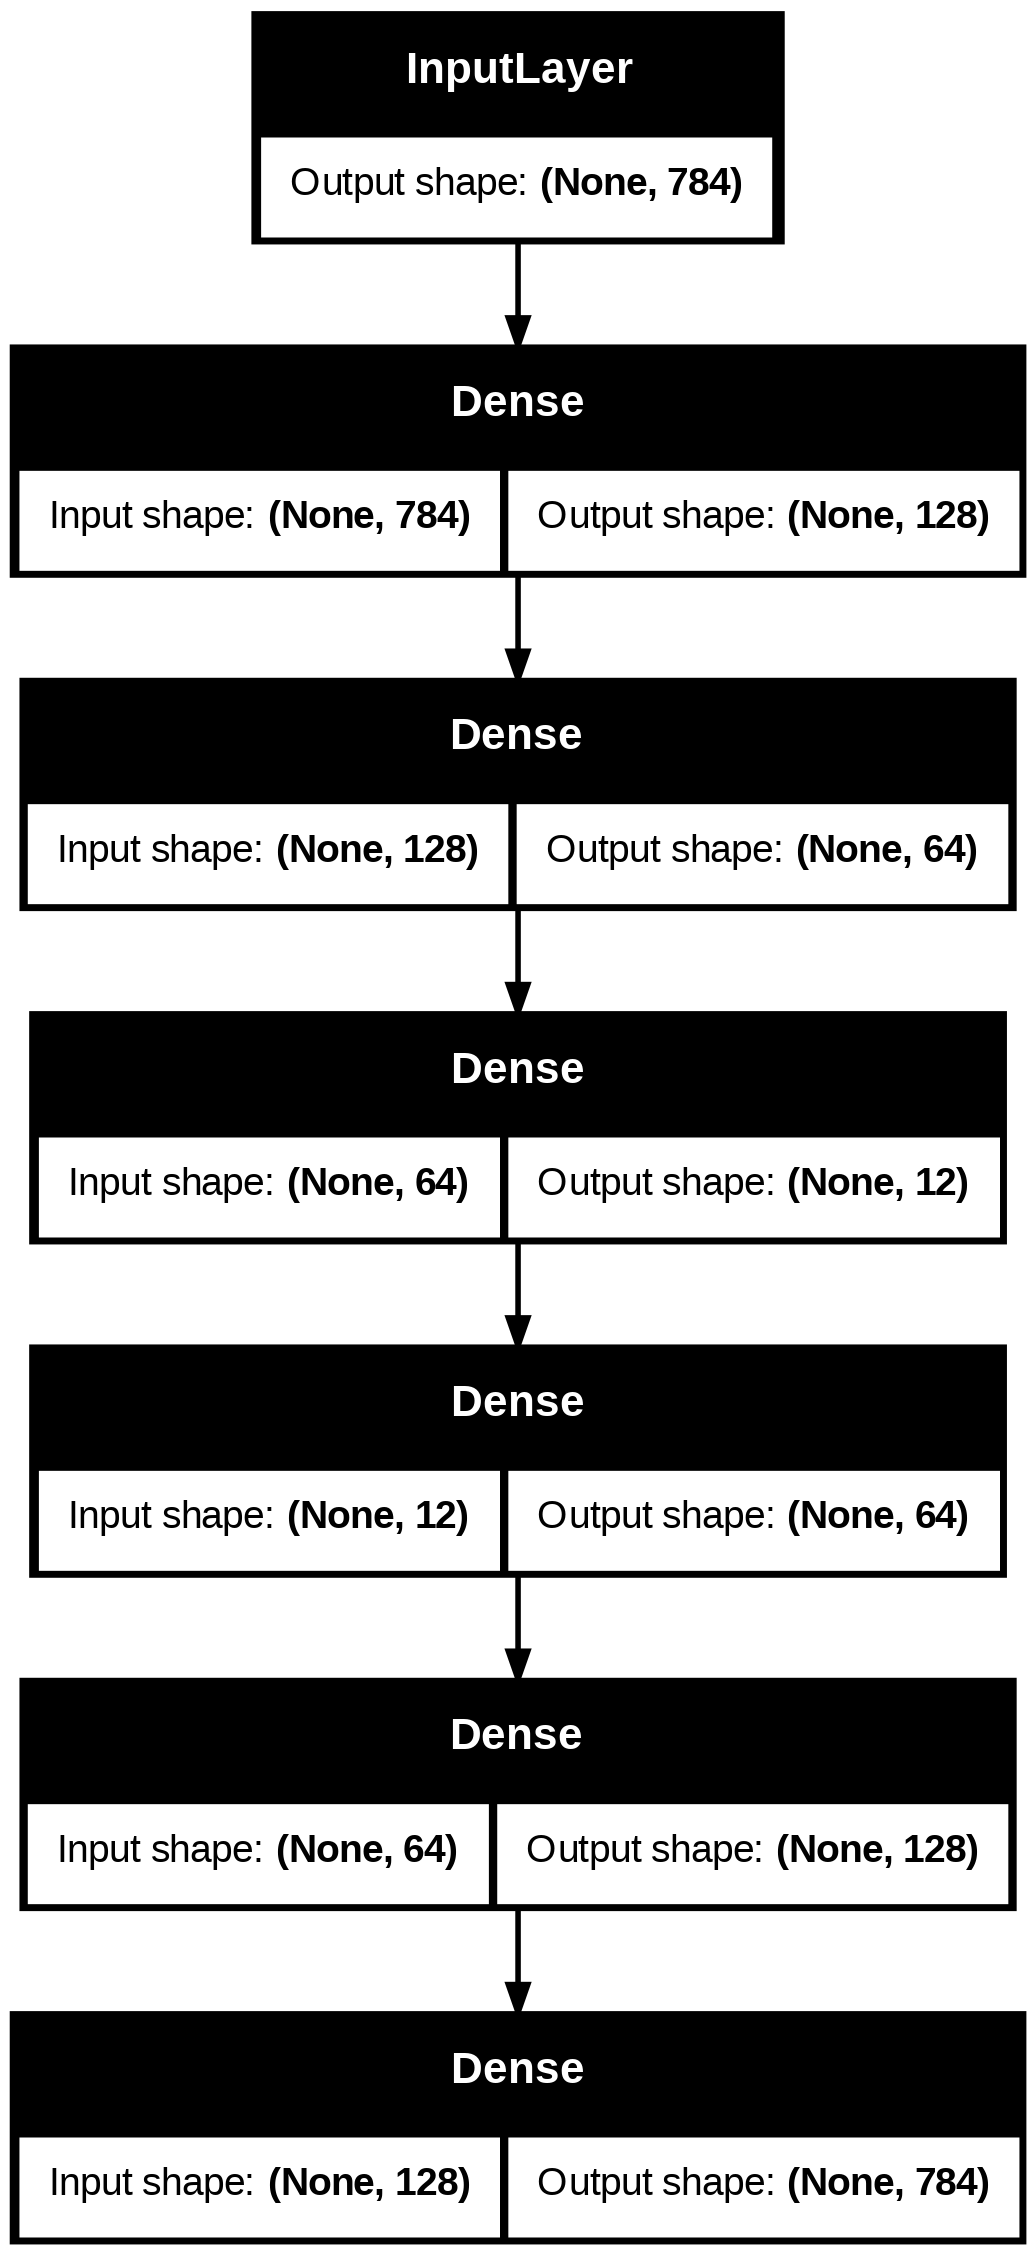

In [17]:
tf.keras.utils.plot_model(autoencoder02, show_shapes=True)

# Criação dos modelos Encoder e Decoder

In [18]:
encoder02 = keras.Model(input_img, encoded)

encoded_input = keras.Input(shape=(encoding_dim,))
decoder_layer = autoencoder02.layers[-3] # número de camadas de saída até a codificação latente
decoder02 = keras.Model(encoded_input, decoder_layer(encoded_input))

# Treinamento do Autoencoder

In [19]:
autoencoder02.compile(optimizer='adam', loss='binary_crossentropy')

history = autoencoder02.fit(x_train, x_train,
                            epochs=100,
                            batch_size=256,
                            shuffle=True,
                            validation_data=(x_test, x_test),
                            verbose=1) # usar 1 ou 2 para observar a evolução por época

Epoch 1/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - loss: 0.3559 - val_loss: 0.1972
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.1858 - val_loss: 0.1588
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1569 - val_loss: 0.1490
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1490 - val_loss: 0.1446
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.1451 - val_loss: 0.1414
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.1417 - val_loss: 0.1390
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1395 - val_loss: 0.1373
Epoch 8/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.1375 - val_loss: 0.1351
Epoch 9/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - loss: 0.1357 - val_loss: 0.1326
Epoch 10/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.1327 - val_loss: 0.1301
Epoch 11/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.1310 - val_loss: 0.1289
Epoch 12/100
235/235 ━━━━━━━━

# Avaliação

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


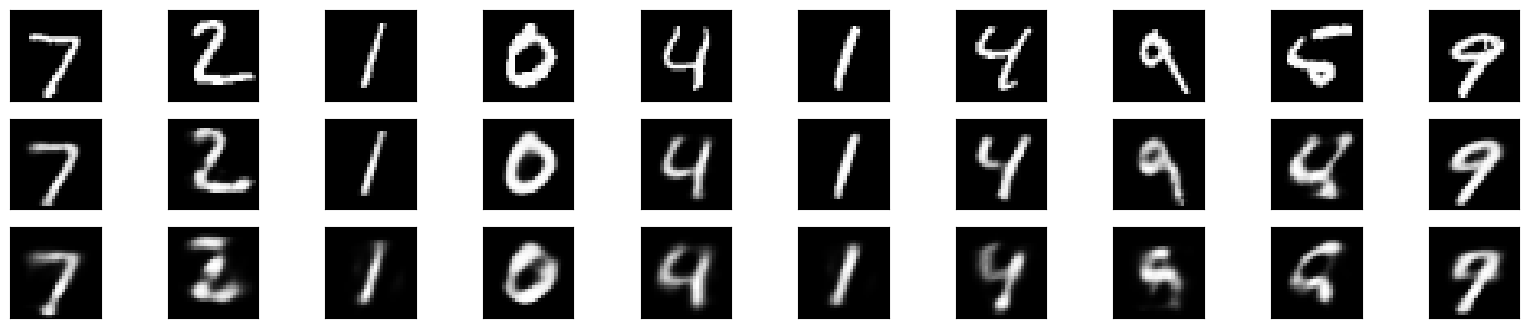

In [20]:
decoded_imgs02 = autoencoder02.predict(x_test)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
  # Original
  ax = plt.subplot(3, n, i + 1)
  plt.imshow(x_test[i].reshape(28, 28))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

  # Reconstrução
  ax = plt.subplot(3, n, i + 1 + n)
  plt.imshow(decoded_imgs02[i].reshape(28, 28))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

  # Reconstrução (raso)
  ax = plt.subplot(3, n, i + 1 + 2*n)
  plt.imshow(decoded_imgs01[i].reshape(28, 28))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
plt.show()

# Projeção PCA

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


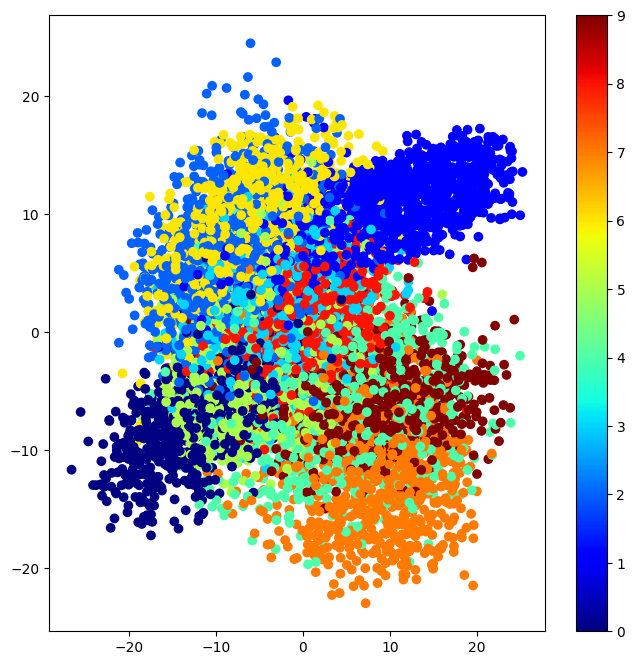

In [22]:
x_test_encoded = encoder02.predict(x_test, batch_size=256)

x_emb = PCA(n_components=2).fit_transform(x_test_encoded)

plt.figure(figsize=(8, 8))
plt.scatter(x_emb[:, 0], x_emb[:, 1], c=y_test, cmap=plt.cm.jet)
plt.colorbar()
plt.show()

# Projeção t-SNE

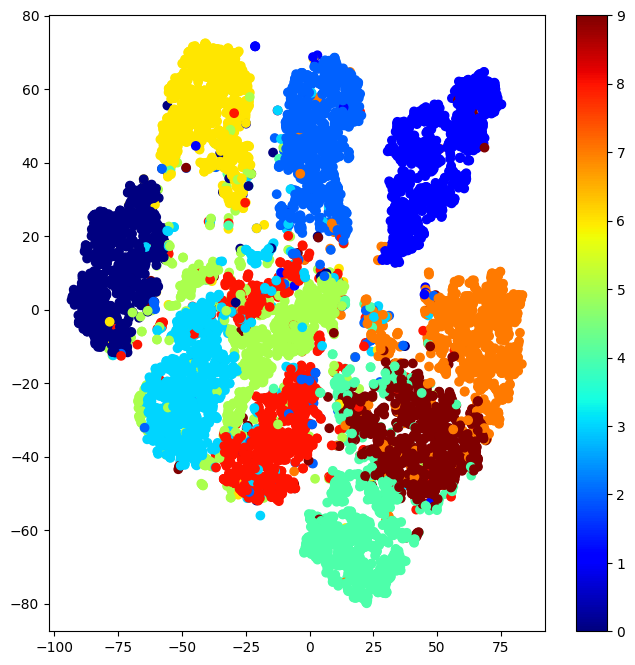

In [23]:
x_emb = TSNE(n_components=2).fit_transform(x_test_encoded)

plt.figure(figsize=(8, 8))
plt.scatter(x_emb[:, 0], x_emb[:, 1], c=y_test, cmap=plt.cm.jet)
plt.colorbar()
plt.show()

# Observações sobre o Espaço Latente

* A dimensão do espaço latente não necessariamente precisa ser menor que a dimensão original
* Podemos usar autoencoders esparsos para ampliar a dimensionalidade de representação do problema
* Os autoencoders esparsos demandam algum tipo de regularização para evitar o aprendizado da solução trivial